In [4]:
!test -d /content/ISS-Conjunction-Screener/.git || git clone https://github.com/AndresPabuence/ISS-Conjunction-Screener.git
%cd /content/ISS-Conjunction-Screener

/content/ISS-Conjunction-Screener


In [5]:
from pathlib import Path

files = [
    "ISS_25544_current.csv",
    "POLYTECH_61747_current.csv",
    "active_satellites.csv",
    "sat000025544.csv",
    "sat000061747.csv"
]

for name in files:
    path = Path("data") / name
    assert path.is_file(), f"Missing: {name}"
    print("OK:", name)

print("ALL INPUT FILES FOUND")

OK: ISS_25544_current.csv
OK: POLYTECH_61747_current.csv
OK: active_satellites.csv
OK: sat000025544.csv
OK: sat000061747.csv
ALL INPUT FILES FOUND


# ISS Conjunction Screening and Historical GP Sensitivity

**Author:** Andres Felipe Pabuence Badillo  
**Date:** October 2026

## Goal

I wanted to build an ISS conjunction screener from public CelesTrak GP data, test it on a known close approach, and then see how much the prediction changes when older GP sets are used.

The final workflow:

- starts from a frozen CelesTrak active-satellite snapshot,
- reduces the catalog with a simple radial pre-filter,
- screens a 72-hour window with SGP4,
- keeps separate close-approach intervals for the same object,
- refines each candidate event numerically,
- compares the closest events with SOCRATES values recorded during the experiment,
- and tracks one ISS–POLYTECH event across historical GP sets.

This is a research/learning project, not an operational collision-avoidance system.

## Research question

How well can a student-built SGP4 screener recover close approaches to the ISS from a frozen CelesTrak GP snapshot, and how much can the predicted TCA and miss distance change when the GP set changes?

## 1. Setup and imports

In [6]:
!pip install -q sgp4==2.27

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.1/218.1 kB 7.3 MB/s eta 0:00:00


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta, timezone
from scipy.optimize import minimize_scalar

from sgp4.api import Satrec, SatrecArray, jday
from sgp4 import omm


## 2. Input data

Files used in this run:

- `ISS_25544_current.csv`
- `POLYTECH_61747_current.csv`
- `active_satellites.csv`
- `sat000025544.csv`
- `sat000061747.csv`

The GP records come from CelesTrak and use the OMM-style CSV fields. The notebook is intentionally tied to these saved files; using newer GP data will change the predictions.

Useful references:

- CelesTrak GP data and formats: https://celestrak.org/NORAD/documentation/gp-data-formats.php
- SOCRATES Plus: https://celestrak.org/SOCRATES/
- Python SGP4 package: https://pypi.org/project/sgp4/

SOCRATES is updated repeatedly as new GP sets arrive. The comparison values later in the notebook are the values I recorded for this experiment, not a claim that the live SOCRATES page will always show the same numbers.

In [8]:
from pathlib import Path

DATA_DIR = Path("data") if Path("data").is_dir() else Path(".")

iss = pd.read_csv(DATA_DIR / "ISS_25544_current.csv")
polytech = pd.read_csv(DATA_DIR / "POLYTECH_61747_current.csv")
active = pd.read_csv(DATA_DIR / "active_satellites.csv")

print("ISS data:")
display(iss[["OBJECT_NAME", "NORAD_CAT_ID", "EPOCH"]])

print("\nPOLYTECH data:")
display(polytech[["OBJECT_NAME", "NORAD_CAT_ID", "EPOCH"]])

print("\nObjects in active-satellite snapshot:", len(active))


ISS data:


,OBJECT_NAME,NORAD_CAT_ID,EPOCH
0,ISS (ZARYA),25544,2026-10-03T01:06:34.599456



POLYTECH data:


,OBJECT_NAME,NORAD_CAT_ID,EPOCH
0,POLYTECH UNIVERSE-4,61747,2026-10-03T05:45:00.741888



Objects in active-satellite snapshot: 16636


## 3. SGP4 helper functions

In [9]:
def initialize_satellite(df):
    fields = {
        key: str(value)
        for key, value in df.iloc[0].to_dict().items()
    }

    satellite = Satrec()
    omm.initialize(satellite, fields)
    return satellite


def initialize_satellite_from_row(row):
    fields = {
        key: str(value)
        for key, value in row.to_dict().items()
    }

    satellite = Satrec()
    omm.initialize(satellite, fields)
    return satellite


def propagate_satellite(satellite, time_utc):
    jd, fr = jday(
        time_utc.year,
        time_utc.month,
        time_utc.day,
        time_utc.hour,
        time_utc.minute,
        time_utc.second + time_utc.microsecond / 1e6
    )

    error, position, velocity = satellite.sgp4(jd, fr)

    if error != 0:
        raise RuntimeError(f"SGP4 error code: {error}")

    return np.array(position), np.array(velocity)


def relative_state(sat1, sat2, time_utc):
    pos1, vel1 = propagate_satellite(sat1, time_utc)
    pos2, vel2 = propagate_satellite(sat2, time_utc)

    relative_position = pos1 - pos2
    relative_velocity = vel1 - vel2

    separation = np.linalg.norm(relative_position)
    relative_speed = np.linalg.norm(relative_velocity)

    return separation, relative_speed


iss_sat = initialize_satellite(iss)
polytech_sat = initialize_satellite(polytech)

print("ISS NORAD:", iss_sat.satnum)
print("POLYTECH NORAD:", polytech_sat.satnum)


ISS NORAD: 25544
POLYTECH NORAD: 61747


## 4. Catalog preparation and radial pre-filter

Propagating every object over the full time grid is expensive, so I first use a simple radial filter. I estimate perigee and apogee from mean motion and eccentricity, then keep objects whose radial range overlaps a ±50 km band around the ISS orbit.

This is only a computational pre-filter. The GP values are mean elements, so I do not treat this step as a formal completeness proof.

In [10]:
MU_EARTH = 398600.4418   # km^3/s^2
R_EARTH = 6378.137       # km


def add_orbital_altitudes(df):
    result = df.copy()

    # Mean motion: revolutions/day -> radians/second
    n = result["MEAN_MOTION"] * 2 * np.pi / 86400

    # Semi-major axis from Kepler's third law
    a = (MU_EARTH / n**2) ** (1 / 3)

    e = result["ECCENTRICITY"]

    result["PERIGEE_KM"] = a * (1 - e) - R_EARTH
    result["APOGEE_KM"] = a * (1 + e) - R_EARTH

    return result


active_orbits = add_orbital_altitudes(active)
iss_orbit = add_orbital_altitudes(iss)

iss_perigee = iss_orbit.loc[0, "PERIGEE_KM"]
iss_apogee = iss_orbit.loc[0, "APOGEE_KM"]

SCREENING_MARGIN_KM = 50.0
radial_min = iss_perigee - SCREENING_MARGIN_KM
radial_max = iss_apogee + SCREENING_MARGIN_KM

screening_candidates = active_orbits[
    (active_orbits["APOGEE_KM"] >= radial_min)
    & (active_orbits["PERIGEE_KM"] <= radial_max)
    & (active_orbits["NORAD_CAT_ID"] != 25544)
    & (~active_orbits["OBJECT_NAME"].astype(str).str.startswith("ISS"))
].dropna(
    subset=["PERIGEE_KM", "APOGEE_KM", "EPOCH"]
).copy()

# ISS modules and docked vehicles present in this snapshot.
# This list has to be checked again if the source snapshot changes.
iss_related_ids = {
    25544,   # ISS (ZARYA)
    25575,   # ISS (UNITY)
    26400,   # ISS (ZVEZDA)
    26700,   # ISS (DESTINY)
    36086,   # POISK
    49044,   # ISS (NAUKA)
    67796,   # CREW DRAGON 12
    68689,   # CYGNUS NG-24
    68837,   # PROGRESS-MS 34
    100057,  # SOYUZ-MS 29
    100712,  # PROGRESS-MS 35
    100882   # CREW DRAGON 13
}

full_candidates = (
    screening_candidates[
        ~screening_candidates["NORAD_CAT_ID"].isin(iss_related_ids)
    ]
    .drop_duplicates(subset="NORAD_CAT_ID")
    .reset_index(drop=True)
)

print(f"ISS perigee proxy: {iss_perigee:.2f} km")
print(f"ISS apogee proxy:  {iss_apogee:.2f} km")
print(f"Radial screening band: {radial_min:.1f}–{radial_max:.1f} km")
print("Original active-satellite snapshot:", len(active_orbits))
print("After radial pre-filter:", len(screening_candidates))
print("Objects entering full screen:", len(full_candidates))

polytech_candidate = full_candidates[
    full_candidates["NORAD_CAT_ID"] == 61747
]

print("POLYTECH retained by pre-filter:", len(polytech_candidate) == 1)

ISS perigee proxy: 415.77 km
ISS apogee proxy:  425.15 km
Radial screening band: 365.8–475.2 km
Original active-satellite snapshot: 16636
After radial pre-filter: 7025
Objects entering full screen: 7018
POLYTECH retained by pre-filter: True


## 5. Time window and coarse gate

The screen covers 72 hours and samples the catalog every 20 seconds. The final distance threshold is 50 km.

A close approach can happen between samples, so the coarse gate needs to be wider than 50 km. I used 22 km/s as a conservative relative-speed bound. The nearest 20-second sample is at most 10 seconds from an event, so the timing allowance is 220 km:

**coarse gate = 50 km + 220 km = 270 km**

Anything that enters this gate is kept for local refinement.

In [11]:
iss_epoch = pd.to_datetime(
    iss.loc[0, "EPOCH"],
    utc=True
).to_pydatetime()

polytech_epoch = pd.to_datetime(
    polytech.loc[0, "EPOCH"],
    utc=True
).to_pydatetime()

search_start = max(iss_epoch, polytech_epoch)

FULL_STEP_SECONDS = 20
FINAL_SCREEN_THRESHOLD_KM = 50.0
CONSERVATIVE_RELATIVE_SPEED_KM_S = 22.0

sampling_margin_km = (
    CONSERVATIVE_RELATIVE_SPEED_KM_S
    * FULL_STEP_SECONDS
    / 2
)

coarse_gate_km = (
    FINAL_SCREEN_THRESHOLD_KM
    + sampling_margin_km
)

full_search_seconds = np.arange(
    0,
    72 * 3600 + FULL_STEP_SECONDS,
    FULL_STEP_SECONDS
)

full_search_times = [
    search_start + timedelta(seconds=int(s))
    for s in full_search_seconds
]

full_jd = []
full_fr = []

for t in full_search_times:
    jd, fr = jday(
        t.year,
        t.month,
        t.day,
        t.hour,
        t.minute,
        t.second + t.microsecond / 1e6
    )

    full_jd.append(jd)
    full_fr.append(fr)

full_jd = np.array(full_jd)
full_fr = np.array(full_fr)

print("Screening start:", search_start)
print("Objects to screen:", len(full_candidates))
print("Time resolution:", FULL_STEP_SECONDS, "seconds")
print("Time samples:", len(full_jd))
print("Coarse gate:", coarse_gate_km, "km")


Screening start: 2026-10-03 05:45:00.741888+00:00
Objects to screen: 7018
Time resolution: 20 seconds
Time samples: 12961
Coarse gate: 270.0 km


## 6. Reference-case check against SOCRATES

Before running the full catalog, I use one ISS–POLYTECH case as a control. The exact historical GP rows used for this case are selected below.

I first search the full 72-hour window at 1-second spacing and then refine the best point to sub-second timing. The SOCRATES numbers shown here are the values recorded during the experiment. Since SOCRATES is regenerated as GP data change, its live table can later show a different prediction for the same pair of objects.

In [12]:
iss_history = pd.read_csv(DATA_DIR / "sat000025544.csv")
polytech_history = pd.read_csv(DATA_DIR / "sat000061747.csv")

iss_history = (
    iss_history
    .drop_duplicates(subset="EPOCH")
    .sort_values("EPOCH")
    .reset_index(drop=True)
)

polytech_history = (
    polytech_history
    .drop_duplicates(subset="EPOCH")
    .sort_values("EPOCH")
    .reset_index(drop=True)
)

iss_history["EPOCH_DT"] = pd.to_datetime(
    iss_history["EPOCH"],
    utc=True
)

polytech_history["EPOCH_DT"] = pd.to_datetime(
    polytech_history["EPOCH"],
    utc=True
)

print("ISS historical epochs:", len(iss_history))
print("POLYTECH historical epochs:", len(polytech_history))


def satellite_from_history_row(row):
    fields = {
        key: str(row[key])
        for key in row.index
        if key != "EPOCH_DT"
    }

    satellite = Satrec()
    omm.initialize(satellite, fields)
    return satellite


iss_validation_row = iss_history[
    iss_history["EPOCH"] == "2026-10-03T01:06:34.599456"
].iloc[0]

polytech_validation_row = polytech_history[
    polytech_history["EPOCH"] == "2026-10-03T05:45:00.741888"
].iloc[0]

iss_validation_sat = satellite_from_history_row(
    iss_validation_row
)

polytech_validation_sat = satellite_from_history_row(
    polytech_validation_row
)

print("ISS validation epoch:", iss_validation_row["EPOCH"])
print("POLYTECH validation epoch:", polytech_validation_row["EPOCH"])


ISS historical epochs: 11
POLYTECH historical epochs: 12
ISS validation epoch: 2026-10-03T01:06:34.599456
POLYTECH validation epoch: 2026-10-03T05:45:00.741888


In [13]:
validation_start = max(
    iss_validation_row["EPOCH_DT"],
    polytech_validation_row["EPOCH_DT"]
).to_pydatetime()

# 72 hours forward at 1-second spacing
validation_offsets = np.arange(
    0,
    72 * 3600 + 1,
    1,
    dtype=float
)

jd0, fr0 = jday(
    validation_start.year,
    validation_start.month,
    validation_start.day,
    validation_start.hour,
    validation_start.minute,
    validation_start.second
    + validation_start.microsecond / 1e6
)

jd_grid = np.full(
    validation_offsets.shape,
    jd0,
    dtype=float
)

fr_grid = fr0 + validation_offsets / 86400.0

carry = np.floor(fr_grid)
jd_grid += carry
fr_grid -= carry

err_iss, pos_iss, _ = iss_validation_sat.sgp4_array(
    jd_grid,
    fr_grid
)

err_poly, pos_poly, _ = polytech_validation_sat.sgp4_array(
    jd_grid,
    fr_grid
)

validation_distances = np.linalg.norm(
    pos_iss - pos_poly,
    axis=1
)

invalid = (err_iss != 0) | (err_poly != 0)
validation_distances[invalid] = np.nan

best_index = int(np.nanargmin(validation_distances))

coarse_validation_tca = validation_start + timedelta(
    seconds=float(validation_offsets[best_index])
)

coarse_validation_distance = float(
    validation_distances[best_index]
)

print("1-SECOND GLOBAL SEARCH")
print("-" * 50)
print("Start:", validation_start)
print("Valid samples:", np.sum(~np.isnan(validation_distances)))
print("Best time:", coarse_validation_tca)
print(f"Best distance: {coarse_validation_distance:.6f} km")


1-SECOND GLOBAL SEARCH
--------------------------------------------------
Start: 2026-10-03 05:45:00.741888+00:00
Valid samples: 259201
Best time: 2026-10-05 10:36:27.741888+00:00
Best distance: 4.398947 km


In [14]:
def distance_near_validation_coarse(offset_seconds):
    t = coarse_validation_tca + timedelta(
        seconds=float(offset_seconds)
    )

    distance, _ = relative_state(
        iss_validation_sat,
        polytech_validation_sat,
        t
    )

    return distance


refined_result = minimize_scalar(
    distance_near_validation_coarse,
    bounds=(-1.0, 1.0),
    method="bounded",
    options={"xatol": 1e-6}
)

validated_tca = coarse_validation_tca + timedelta(
    seconds=float(refined_result.x)
)

validated_distance, validated_speed = relative_state(
    iss_validation_sat,
    polytech_validation_sat,
    validated_tca
)

recorded_socrates_tca = datetime(
    2026, 10, 5,
    10, 36, 27, 478000,
    tzinfo=timezone.utc
)
recorded_socrates_distance_km = 3.942
recorded_socrates_speed_km_s = 7.385

print("REFINED REFERENCE CASE")
print("-" * 50)
print("Computed TCA:", validated_tca)
print(f"Computed minimum distance: {validated_distance:.6f} km")
print(f"Computed relative speed: {validated_speed:.6f} km/s")
print()
print("SOCRATES values recorded for this experiment:")
print("Recorded TCA:", recorded_socrates_tca)
print(f"Recorded distance: {recorded_socrates_distance_km:.3f} km")
print(f"Recorded speed: {recorded_socrates_speed_km_s:.3f} km/s")
print()
print(
    "TCA difference from recorded SOCRATES value:",
    abs((validated_tca - recorded_socrates_tca).total_seconds()),
    "s"
)

REFINED REFERENCE CASE
--------------------------------------------------
Computed TCA: 2026-10-05 10:36:27.477572+00:00
Computed minimum distance: 3.942206 km
Computed relative speed: 7.384565 km/s

SOCRATES values recorded for this experiment:
Recorded TCA: 2026-10-05 10:36:27.478000+00:00
Recorded distance: 3.942 km
Recorded speed: 7.385 km/s

TCA difference from recorded SOCRATES value: 0.000428 s


## 7. Historical GP sensitivity for the same event

For this part I keep the event fixed: the ISS–POLYTECH conjunction validated above. At each GP epoch in the historical files, I select the latest row by **element epoch** for each object and search only ±5 minutes around the validated TCA.

That prevents the calculation from jumping to a different nearby encounter. One important limitation is that the GP `EPOCH` field is being used as the snapshot marker here; it is not the same thing as an exact CelesTrak publication timestamp.

In [15]:
snapshot_times = sorted(
    set(iss_history["EPOCH_DT"]).union(
        set(polytech_history["EPOCH_DT"])
    )
)

first_common_time = max(
    iss_history["EPOCH_DT"].min(),
    polytech_history["EPOCH_DT"].min()
)

snapshot_times = [
    t for t in snapshot_times
    if t >= first_common_time
]


def latest_available_row(df, as_of_time):
    available = df[
        df["EPOCH_DT"] <= as_of_time
    ]

    if len(available) == 0:
        return None

    return available.iloc[-1]


def predict_reference_event(
    sat1,
    sat2,
    reference_tca,
    half_window_seconds=300,
    coarse_step_seconds=1
):
    window_start = reference_tca - timedelta(
        seconds=half_window_seconds
    )

    offsets = np.arange(
        0,
        2 * half_window_seconds + coarse_step_seconds,
        coarse_step_seconds,
        dtype=float
    )

    jd0, fr0 = jday(
        window_start.year,
        window_start.month,
        window_start.day,
        window_start.hour,
        window_start.minute,
        window_start.second
        + window_start.microsecond / 1e6
    )

    jd_grid = np.full(offsets.shape, jd0, dtype=float)
    fr_grid = fr0 + offsets / 86400.0

    carry = np.floor(fr_grid)
    jd_grid += carry
    fr_grid -= carry

    err1, pos1, _ = sat1.sgp4_array(jd_grid, fr_grid)
    err2, pos2, _ = sat2.sgp4_array(jd_grid, fr_grid)

    distances = np.linalg.norm(pos1 - pos2, axis=1)

    invalid = (err1 != 0) | (err2 != 0)
    distances[invalid] = np.nan

    best_index = int(np.nanargmin(distances))

    if best_index == 0 or best_index == len(offsets) - 1:
        raise RuntimeError(
            "Tracked event reached the search-window boundary."
        )

    coarse_time = window_start + timedelta(
        seconds=float(offsets[best_index])
    )

    def local_distance(offset_seconds):
        t = coarse_time + timedelta(
            seconds=float(offset_seconds)
        )

        distance, _ = relative_state(
            sat1,
            sat2,
            t
        )

        return distance

    refined = minimize_scalar(
        local_distance,
        bounds=(-1.0, 1.0),
        method="bounded",
        options={"xatol": 1e-6}
    )

    tca = coarse_time + timedelta(
        seconds=float(refined.x)
    )

    distance, speed = relative_state(
        sat1,
        sat2,
        tca
    )

    return tca, distance, speed


check_tca, check_distance, check_speed = predict_reference_event(
    iss_validation_sat,
    polytech_validation_sat,
    validated_tca
)

print("Historical tracker control")
print("-" * 50)
print("TCA:", check_tca)
print(f"Distance: {check_distance:.6f} km")
print(f"Relative speed: {check_speed:.6f} km/s")
print(
    "TCA difference:",
    abs((check_tca - validated_tca).total_seconds()),
    "s"
)


Historical tracker control
--------------------------------------------------
TCA: 2026-10-05 10:36:27.477572+00:00
Distance: 3.942206 km
Relative speed: 7.384565 km/s
TCA difference: 0.0 s


In [16]:
reference_event_rows = []
failed_snapshots = []

for i, as_of_time in enumerate(snapshot_times, start=1):

    iss_row = latest_available_row(
        iss_history,
        as_of_time
    )

    polytech_row = latest_available_row(
        polytech_history,
        as_of_time
    )

    if iss_row is None or polytech_row is None:
        continue

    hist_iss_sat = satellite_from_history_row(
        iss_row
    )

    hist_polytech_sat = satellite_from_history_row(
        polytech_row
    )

    try:
        predicted_tca, predicted_distance, predicted_speed = (
            predict_reference_event(
                hist_iss_sat,
                hist_polytech_sat,
                validated_tca
            )
        )

        hours_before_event = (
            validated_tca
            - as_of_time.to_pydatetime()
        ).total_seconds() / 3600

        tca_deviation_s = (
            predicted_tca - validated_tca
        ).total_seconds()

        reference_event_rows.append({
            "as_of_time": as_of_time,
            "iss_epoch": iss_row["EPOCH_DT"],
            "polytech_epoch": polytech_row["EPOCH_DT"],
            "hours_before_event": hours_before_event,
            "predicted_tca": predicted_tca,
            "tca_deviation_s": tca_deviation_s,
            "predicted_distance_km": predicted_distance,
            "relative_speed_km_s": predicted_speed
        })

    except Exception as exc:
        failed_snapshots.append({
            "as_of_time": as_of_time,
            "reason": str(exc)
        })


reference_event_history = pd.DataFrame(
    reference_event_rows
)

print("REFERENCE-EVENT HISTORICAL SUMMARY")
print("-" * 55)
print("Successful snapshots:", len(reference_event_history))
print("Failed snapshots:", len(failed_snapshots))

print(
    f"Predicted distance range: "
    f"{reference_event_history['predicted_distance_km'].min():.3f}"
    f"–"
    f"{reference_event_history['predicted_distance_km'].max():.3f} km"
)

print(
    f"Distance span: "
    f"{reference_event_history['predicted_distance_km'].max() - reference_event_history['predicted_distance_km'].min():.3f} km"
)

print(
    f"TCA shift range: "
    f"{reference_event_history['tca_deviation_s'].min():+.3f}"
    f" to "
    f"{reference_event_history['tca_deviation_s'].max():+.3f} s"
)

print(
    f"Maximum absolute TCA shift: "
    f"{reference_event_history['tca_deviation_s'].abs().max():.3f} s"
)

display(
    reference_event_history[
        [
            "as_of_time",
            "hours_before_event",
            "predicted_tca",
            "predicted_distance_km",
            "tca_deviation_s"
        ]
    ]
)


REFERENCE-EVENT HISTORICAL SUMMARY
-------------------------------------------------------
Successful snapshots: 22
Failed snapshots: 0
Predicted distance range: 0.346–14.844 km
Distance span: 14.498 km
TCA shift range: -0.116 to +1.618 s
Maximum absolute TCA shift: 1.618 s


,as_of_time,hours_before_event,predicted_tca,predicted_distance_km,tca_deviation_s
0,2026-09-30 04:53:11.216256+00:00,125.721184,2026-10-05 10:36:28.604678+00:00,6.784353,1.127106
1,2026-09-30 11:09:48.187584+00:00,119.444247,2026-10-05 10:36:28.358165+00:00,3.547612,0.880593
2,2026-09-30 14:11:18.220704+00:00,116.419238,2026-10-05 10:36:28.552411+00:00,1.018970,1.074839
3,2026-09-30 20:27:19.351584+00:00,110.152257,2026-10-05 10:36:28.464634+00:00,0.345768,0.987062
4,2026-09-30 21:56:23.901792+00:00,108.667660,2026-10-05 10:36:28.365322+00:00,1.276162,0.887750
5,2026-10-01 02:35:27.242016+00:00,104.016732,2026-10-05 10:36:28.649708+00:00,2.602245,1.172136
6,2026-10-01 02:39:00.159264+00:00,103.957588,2026-10-05 10:36:29.095676+00:00,3.537107,1.618104
7,2026-10-01 11:56:31.238592+00:00,94.665622,2026-10-05 10:36:28.830870+00:00,0.406478,1.353298
8,2026-10-01 14:59:35.946240+00:00,91.614314,2026-10-05 10:36:28.466266+00:00,4.995415,0.988694
9,2026-10-01 19:41:07.107360+00:00,86.922325,2026-10-05 10:36:28.455277+00:00,4.974249,0.977705


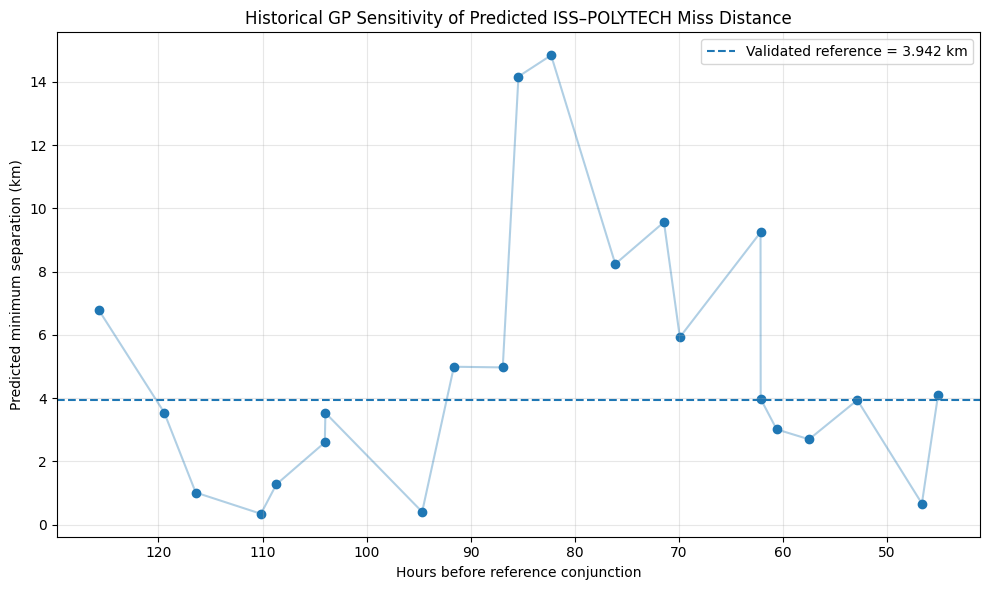

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(
    reference_event_history["hours_before_event"],
    reference_event_history["predicted_distance_km"]
)

plt.plot(
    reference_event_history["hours_before_event"],
    reference_event_history["predicted_distance_km"],
    alpha=0.35
)

plt.axhline(
    validated_distance,
    linestyle="--",
    label=f"Validated reference = {validated_distance:.3f} km"
)

plt.xlabel("Hours before reference conjunction")
plt.ylabel("Predicted minimum separation (km)")
plt.title(
    "Historical GP Sensitivity of Predicted ISS–POLYTECH Miss Distance"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig(
    "historical_gp_sensitivity_distance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


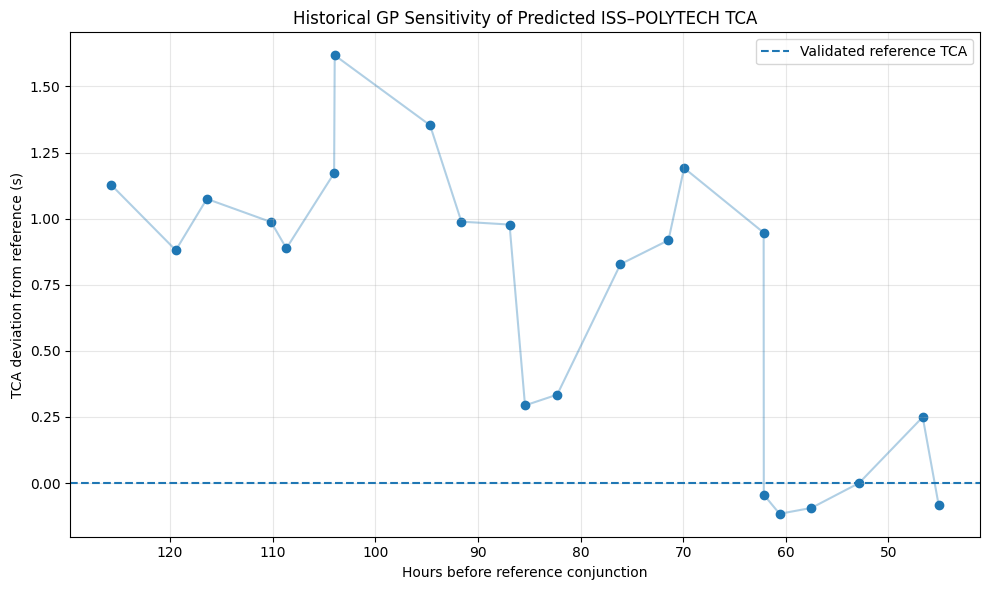

In [18]:
plt.figure(figsize=(10, 6))

plt.scatter(
    reference_event_history["hours_before_event"],
    reference_event_history["tca_deviation_s"]
)

plt.plot(
    reference_event_history["hours_before_event"],
    reference_event_history["tca_deviation_s"],
    alpha=0.35
)

plt.axhline(
    0,
    linestyle="--",
    label="Validated reference TCA"
)

plt.xlabel("Hours before reference conjunction")
plt.ylabel("TCA deviation from reference (s)")
plt.title(
    "Historical GP Sensitivity of Predicted ISS–POLYTECH TCA"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig(
    "historical_gp_sensitivity_tca.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [19]:
reference_event_history.to_csv(
    "ISS_POLYTECH_historical_validation.csv",
    index=False
)

print("Historical validation saved.")


Historical validation saved.


## 8. Catalog-scale screening

A sparse grid can miss a narrow minimum if it keeps only one sampled minimum per object. In the final screen I instead keep every contiguous interval that enters the 270 km coarse gate. Each interval is treated as a separate event and refined independently.

In [20]:
coarse_iss_errors, coarse_iss_positions, _ = iss_sat.sgp4_array(
    full_jd,
    full_fr
)

BLOCK_SIZE = 100

coarse_event_rows = []
initialization_failures = []


def contiguous_true_runs(mask):
    indices = np.flatnonzero(mask)

    if len(indices) == 0:
        return []

    split_points = np.where(
        np.diff(indices) > 1
    )[0] + 1

    return np.split(indices, split_points)


for block_start in range(
    0,
    len(full_candidates),
    BLOCK_SIZE
):
    block_end = min(
        block_start + BLOCK_SIZE,
        len(full_candidates)
    )

    block_df = full_candidates.iloc[
        block_start:block_end
    ]

    block_sats = []
    valid_rows = []

    for _, row in block_df.iterrows():
        try:
            sat = initialize_satellite_from_row(row)
            block_sats.append(sat)
            valid_rows.append(row)

        except Exception as exc:
            initialization_failures.append({
                "NORAD_CAT_ID": int(row["NORAD_CAT_ID"]),
                "OBJECT_NAME": row["OBJECT_NAME"],
                "reason": str(exc)
            })

    if len(block_sats) == 0:
        continue

    sat_array = SatrecArray(block_sats)

    candidate_errors, candidate_positions, _ = sat_array.sgp4(
        full_jd,
        full_fr
    )

    relative_positions = (
        candidate_positions
        - coarse_iss_positions[np.newaxis, :, :]
    )

    separations = np.linalg.norm(
        relative_positions,
        axis=2
    )

    invalid = (
        (candidate_errors != 0)
        | (coarse_iss_errors[np.newaxis, :] != 0)
    )

    separations[invalid] = np.nan

    for i, row in enumerate(valid_rows):
        object_distances = separations[i]

        inside_gate = (
            object_distances <= coarse_gate_km
        )

        runs = contiguous_true_runs(
            inside_gate
        )

        for event_number, run in enumerate(
            runs,
            start=1
        ):
            local_values = object_distances[run]

            best_local_position = int(
                np.nanargmin(local_values)
            )

            best_index = int(
                run[best_local_position]
            )

            coarse_event_rows.append({
                "OBJECT_NAME": row["OBJECT_NAME"],
                "NORAD_CAT_ID": int(row["NORAD_CAT_ID"]),
                "event_number": event_number,
                "coarse_index": best_index,
                "coarse_tca": full_search_times[best_index],
                "coarse_distance_km":
                    float(object_distances[best_index]),
                "gate_start_index": int(run[0]),
                "gate_end_index": int(run[-1]),
                "touches_search_boundary":
                    bool(
                        run[0] == 0
                        or run[-1] == len(full_search_times) - 1
                    )
            })

    if block_end % 500 == 0 or block_end == len(full_candidates):
        print(
            f"Processed {block_end} / {len(full_candidates)}"
        )

    del sat_array
    del candidate_errors
    del candidate_positions
    del relative_positions
    del separations


coarse_events = pd.DataFrame(
    coarse_event_rows
)

if len(coarse_events) > 0:
    coarse_events = (
        coarse_events
        .sort_values("coarse_distance_km")
        .reset_index(drop=True)
    )

print("\nCOARSE GATE COMPLETE")
print("-" * 50)
print("Objects screened:", len(full_candidates))
print("Candidate event intervals:", len(coarse_events))
print(
    "Unique candidate objects:",
    coarse_events["NORAD_CAT_ID"].nunique()
    if len(coarse_events) else 0
)
print(
    "Events touching 72-h boundary:",
    int(coarse_events["touches_search_boundary"].sum())
    if len(coarse_events) else 0
)
print("Initialization failures:", len(initialization_failures))


Processed 500 / 7018
Processed 1000 / 7018
Processed 1500 / 7018
Processed 2000 / 7018
Processed 2500 / 7018
Processed 3000 / 7018
Processed 3500 / 7018
Processed 4000 / 7018
Processed 4500 / 7018
Processed 5000 / 7018
Processed 5500 / 7018
Processed 6000 / 7018
Processed 6500 / 7018
Processed 7000 / 7018
Processed 7018 / 7018

COARSE GATE COMPLETE
--------------------------------------------------
Objects screened: 7018
Candidate event intervals: 11645
Unique candidate objects: 3205
Events touching 72-h boundary: 3
Initialization failures: 0


### 8.1 Control check on the POLYTECH event

In [21]:
polytech_coarse_events = coarse_events[
    coarse_events["NORAD_CAT_ID"] == 61747
].copy()

polytech_coarse_events["time_difference_from_reference_s"] = (
    pd.to_datetime(
        polytech_coarse_events["coarse_tca"],
        utc=True
    )
    - pd.Timestamp(validated_tca)
).dt.total_seconds().abs()

polytech_coarse_control = (
    polytech_coarse_events
    .sort_values("time_difference_from_reference_s")
    .iloc[0]
)

polytech_full_row = full_candidates[
    full_candidates["NORAD_CAT_ID"] == 61747
].iloc[0]

polytech_full_sat = initialize_satellite_from_row(
    polytech_full_row
)

coarse_center = polytech_coarse_control["coarse_tca"]

if hasattr(coarse_center, "to_pydatetime"):
    coarse_center = coarse_center.to_pydatetime()


def refine_coarse_event(
    primary_sat,
    secondary_sat,
    coarse_time,
    search_half_width=20.0
):
    def distance_at_offset(offset_s):
        t = coarse_time + timedelta(
            seconds=float(offset_s)
        )

        distance, _ = relative_state(
            primary_sat,
            secondary_sat,
            t
        )

        return distance

    result = minimize_scalar(
        distance_at_offset,
        bounds=(-search_half_width, search_half_width),
        method="bounded",
        options={"xatol": 1e-6}
    )

    refined_tca = coarse_time + timedelta(
        seconds=float(result.x)
    )

    refined_distance, refined_speed = relative_state(
        primary_sat,
        secondary_sat,
        refined_tca
    )

    return (
        refined_tca,
        refined_distance,
        refined_speed
    )


test_tca, test_distance, test_speed = refine_coarse_event(
    iss_sat,
    polytech_full_sat,
    coarse_center
)

print("GENERIC REFINER — POLYTECH CONTROL")
print("-" * 55)
print("Coarse TCA:", coarse_center)
print(
    f"Coarse distance: "
    f"{polytech_coarse_control['coarse_distance_km']:.6f} km"
)
print("Refined TCA:", test_tca)
print(f"Refined distance: {test_distance:.6f} km")
print(f"Relative speed: {test_speed:.6f} km/s")
print(
    "TCA difference from validated reference:",
    abs((test_tca - validated_tca).total_seconds()),
    "s"
)
print(
    "Distance difference from validated reference:",
    abs(test_distance - validated_distance) * 1000,
    "m"
)


GENERIC REFINER — POLYTECH CONTROL
-------------------------------------------------------
Coarse TCA: 2026-10-05 10:36:20.741888+00:00
Coarse distance: 49.895595 km
Refined TCA: 2026-10-05 10:36:27.477572+00:00
Refined distance: 3.942206 km
Relative speed: 7.384565 km/s
TCA difference from validated reference: 0.0 s
Distance difference from validated reference: 0.0 m


### 8.2 Refine all candidate intervals

In [22]:
candidate_satellites = {}

for _, row in full_candidates.iterrows():
    norad_id = int(row["NORAD_CAT_ID"])
    candidate_satellites[norad_id] = (
        initialize_satellite_from_row(row)
    )

print(
    "Satellites available for refinement:",
    len(candidate_satellites)
)


refined_event_rows = []
boundary_event_rows = []
refinement_failures = []

total_events = len(coarse_events)

for i, event in coarse_events.iterrows():

    if event["touches_search_boundary"]:
        boundary_event_rows.append(
            event.to_dict()
        )
        continue

    norad_id = int(event["NORAD_CAT_ID"])

    try:
        secondary_sat = candidate_satellites[
            norad_id
        ]

        coarse_time = event["coarse_tca"]

        if hasattr(coarse_time, "to_pydatetime"):
            coarse_time = coarse_time.to_pydatetime()

        refined_tca, refined_distance, refined_speed = (
            refine_coarse_event(
                iss_sat,
                secondary_sat,
                coarse_time,
                search_half_width=20.0
            )
        )

        refined_event_rows.append({
            "OBJECT_NAME": event["OBJECT_NAME"],
            "NORAD_CAT_ID": norad_id,
            "event_number": int(event["event_number"]),
            "coarse_tca": event["coarse_tca"],
            "coarse_distance_km": float(
                event["coarse_distance_km"]
            ),
            "refined_tca": refined_tca,
            "refined_distance_km": refined_distance,
            "relative_speed_km_s": refined_speed
        })

    except Exception as exc:
        refinement_failures.append({
            "OBJECT_NAME": event["OBJECT_NAME"],
            "NORAD_CAT_ID": norad_id,
            "event_number": int(event["event_number"]),
            "reason": str(exc)
        })

    if (i + 1) % 500 == 0:
        print(
            f"Refined {i + 1} / {total_events}"
        )


refined_events = pd.DataFrame(
    refined_event_rows
)

refined_events = (
    refined_events
    .sort_values("refined_distance_km")
    .reset_index(drop=True)
)

print("\nFULL REFINEMENT COMPLETE")
print("-" * 55)
print("Refined events:", len(refined_events))
print("Boundary events held out:", len(boundary_event_rows))
print("Refinement failures:", len(refinement_failures))
print(
    "Events below 50 km:",
    (
        refined_events[
            "refined_distance_km"
        ] < FINAL_SCREEN_THRESHOLD_KM
    ).sum()
)


Satellites available for refinement: 7018
Refined 500 / 11645
Refined 1000 / 11645
Refined 1500 / 11645
Refined 2000 / 11645
Refined 2500 / 11645
Refined 3000 / 11645
Refined 3500 / 11645
Refined 4000 / 11645
Refined 4500 / 11645
Refined 5000 / 11645
Refined 5500 / 11645
Refined 6000 / 11645
Refined 6500 / 11645
Refined 7000 / 11645
Refined 7500 / 11645
Refined 8000 / 11645
Refined 8500 / 11645
Refined 9000 / 11645
Refined 9500 / 11645
Refined 10000 / 11645
Refined 10500 / 11645
Refined 11000 / 11645
Refined 11500 / 11645

FULL REFINEMENT COMPLETE
-------------------------------------------------------
Refined events: 11642
Boundary events held out: 3
Refinement failures: 0
Events below 50 km: 878


### 8.3 Check intervals that touch the 72-hour boundaries

In [23]:
boundary_events = coarse_events[
    coarse_events["touches_search_boundary"]
].copy()

boundary_events["boundary_side"] = np.where(
    boundary_events["gate_start_index"] == 0,
    "START",
    np.where(
        boundary_events["gate_end_index"]
        == len(full_search_times) - 1,
        "END",
        "UNKNOWN"
    )
)


def inspect_boundary_event(
    event,
    extension_seconds=300
):
    norad_id = int(event["NORAD_CAT_ID"])
    secondary_sat = candidate_satellites[norad_id]

    coarse_time = event["coarse_tca"]

    if hasattr(coarse_time, "to_pydatetime"):
        coarse_time = coarse_time.to_pydatetime()

    offsets = np.arange(
        -extension_seconds,
        extension_seconds + 1,
        1,
        dtype=float
    )

    distances = []

    for offset in offsets:
        t = coarse_time + timedelta(
            seconds=float(offset)
        )

        distance, _ = relative_state(
            iss_sat,
            secondary_sat,
            t
        )

        distances.append(distance)

    distances = np.array(distances)

    best_idx = int(np.argmin(distances))

    grid_best_time = coarse_time + timedelta(
        seconds=float(offsets[best_idx])
    )

    refined_tca, refined_distance, refined_speed = refine_coarse_event(
        iss_sat,
        secondary_sat,
        grid_best_time,
        search_half_width=1.0
    )

    window_start = full_search_times[0]
    window_end = full_search_times[-1]

    if hasattr(window_start, "to_pydatetime"):
        window_start = window_start.to_pydatetime()

    if hasattr(window_end, "to_pydatetime"):
        window_end = window_end.to_pydatetime()

    inside_window = (
        window_start <= refined_tca <= window_end
    )

    return {
        "OBJECT_NAME": event["OBJECT_NAME"],
        "NORAD_CAT_ID": norad_id,
        "event_number": int(event["event_number"]),
        "coarse_tca": event["coarse_tca"],
        "coarse_distance_km": float(event["coarse_distance_km"]),
        "boundary_side": event["boundary_side"],
        "refined_tca": refined_tca,
        "refined_distance_km": refined_distance,
        "relative_speed_km_s": refined_speed,
        "inside_72h_window": inside_window
    }


boundary_checks = pd.DataFrame([
    inspect_boundary_event(event)
    for _, event in boundary_events.iterrows()
])


# If a boundary interval has its refined TCA inside the requested
# 72-hour window, keep it with the other refined events.
if len(boundary_checks):
    boundary_inside = boundary_checks[
        boundary_checks["inside_72h_window"]
    ].copy()

    if len(boundary_inside):
        boundary_inside = boundary_inside[
            [
                "OBJECT_NAME",
                "NORAD_CAT_ID",
                "event_number",
                "coarse_tca",
                "coarse_distance_km",
                "refined_tca",
                "refined_distance_km",
                "relative_speed_km_s"
            ]
        ]

        refined_events = pd.concat(
            [refined_events, boundary_inside],
            ignore_index=True
        )

        refined_events = (
            refined_events
            .sort_values("refined_distance_km")
            .reset_index(drop=True)
        )

print("BOUNDARY EVENTS")
print("-" * 60)

if len(boundary_checks):
    print(boundary_checks.to_string(index=False))
else:
    print("None")

BOUNDARY EVENTS
------------------------------------------------------------
   OBJECT_NAME  NORAD_CAT_ID  event_number                       coarse_tca  coarse_distance_km boundary_side                      refined_tca  refined_distance_km  relative_speed_km_s  inside_72h_window
     SKYSAT-C3         41774             1 2026-10-03 05:45:00.741888+00:00          178.085547         START 2026-10-03 05:44:58.982329+00:00           176.184154            14.751507              False
STARLINK-34921         65893             2 2026-10-06 05:45:00.741888+00:00          181.052410           END 2026-10-06 05:50:01.741887+00:00           115.567701             0.247476              False
STARLINK-37844        100028             5 2026-10-06 05:45:00.741888+00:00          259.690131           END 2026-10-06 05:45:05.438967+00:00           253.387104            12.110150              False


## 9. Final screening results and sanity checks

In [24]:
final_events = (
    refined_events[
        refined_events["refined_distance_km"]
        < FINAL_SCREEN_THRESHOLD_KM
    ]
    .copy()
    .sort_values(
        [
            "refined_distance_km",
            "refined_tca"
        ]
    )
    .reset_index(drop=True)
)

final_events.insert(
    0,
    "event_rank",
    np.arange(1, len(final_events) + 1)
)

print("FINAL SCREENING RESULTS")
print("-" * 60)
print("Events below 50 km:", len(final_events))
print(
    "Unique objects represented:",
    final_events["NORAD_CAT_ID"].nunique()
)

print("\nTOP 25 CLOSEST EVENTS")

print(
    final_events[
        [
            "event_rank",
            "OBJECT_NAME",
            "NORAD_CAT_ID",
            "refined_tca",
            "refined_distance_km",
            "relative_speed_km_s"
        ]
    ]
    .head(25)
    .to_string(index=False)
)


FINAL SCREENING RESULTS
------------------------------------------------------------
Events below 50 km: 878
Unique objects represented: 816

TOP 25 CLOSEST EVENTS
 event_rank              OBJECT_NAME  NORAD_CAT_ID                      refined_tca  refined_distance_km  relative_speed_km_s
          1              SHERPA-LTC2         53754 2026-10-04 21:04:51.303672+00:00             1.989251             0.333873
          2               2024-199AU         61777 2026-10-04 13:40:32.141116+00:00             2.693989             7.019402
          3      POLYTECH UNIVERSE-4         61747 2026-10-05 10:36:27.477572+00:00             3.942206             7.384565
          4                2025-155K         64885 2026-10-04 13:12:46.342911+00:00             5.414765            13.700667
          5                    BRO-5         51061 2026-10-03 22:18:37.076409+00:00            11.788906            13.605909
          6           SUPERVIEW-1 03         43099 2026-10-04 05:19:06.553287+00

In [25]:
print("FINAL DATASET INTEGRITY CHECK")
print("-" * 60)

duplicate_events = final_events.duplicated(
    subset=[
        "NORAD_CAT_ID",
        "event_number"
    ]
).sum()

invalid_distances = (
    ~np.isfinite(final_events["refined_distance_km"])
    | (final_events["refined_distance_km"] < 0)
).sum()

invalid_speeds = (
    ~np.isfinite(final_events["relative_speed_km_s"])
    | (final_events["relative_speed_km_s"] < 0)
).sum()

above_threshold = (
    final_events["refined_distance_km"]
    >= FINAL_SCREEN_THRESHOLD_KM
).sum()

analysis_start = full_search_times[0]
analysis_end = full_search_times[-1]

outside_window = (
    (final_events["refined_tca"] < analysis_start)
    | (final_events["refined_tca"] > analysis_end)
).sum()

events_below_5 = final_events[
    final_events["refined_distance_km"] < 5.0
].copy()

print("Final events:", len(final_events))
print(
    "Unique objects:",
    final_events["NORAD_CAT_ID"].nunique()
)
print("Duplicate object-event pairs:", duplicate_events)
print("Invalid distances:", invalid_distances)
print("Invalid relative speeds:", invalid_speeds)
print("Events incorrectly >= 50 km:", above_threshold)
print("Final events outside 72-h window:", outside_window)
print("Events below 5 km:", len(events_below_5))

display(
    events_below_5[
        [
            "event_rank",
            "OBJECT_NAME",
            "NORAD_CAT_ID",
            "refined_tca",
            "refined_distance_km",
            "relative_speed_km_s"
        ]
    ]
)


FINAL DATASET INTEGRITY CHECK
------------------------------------------------------------
Final events: 878
Unique objects: 816
Duplicate object-event pairs: 0
Invalid distances: 0
Invalid relative speeds: 0
Events incorrectly >= 50 km: 0
Final events outside 72-h window: 0
Events below 5 km: 3


,event_rank,OBJECT_NAME,NORAD_CAT_ID,refined_tca,refined_distance_km,relative_speed_km_s
0,1,SHERPA-LTC2,53754,2026-10-04 21:04:51.303672+00:00,1.989251,0.333873
1,2,2024-199AU,61777,2026-10-04 13:40:32.141116+00:00,2.693989,7.019402
2,3,POLYTECH UNIVERSE-4,61747,2026-10-05 10:36:27.477572+00:00,3.942206,7.384565


## 10. Comparison with the SOCRATES values recorded during the experiment

The table below compares the three closest recovered ISS encounters with the SOCRATES range and relative-speed values I recorded while testing this frozen GP snapshot.

SOCRATES is a live service and is recalculated as newer GP sets arrive, so a later visit to the site can show different predictions. The small differences below are only differences from the rounded values that were recorded; they are **not** evidence of sub-meter physical accuracy.

In [26]:
socrates_reference = pd.DataFrame([
    {
        "NORAD_CAT_ID": 53754,
        "SOCRATES_OBJECT_NAME": "SHERPA-LTC2",
        "socrates_recorded_distance_km": 1.989,
        "socrates_recorded_speed_km_s": 0.334
    },
    {
        "NORAD_CAT_ID": 61777,
        "SOCRATES_OBJECT_NAME": "OBJECT AU",
        "socrates_recorded_distance_km": 2.694,
        "socrates_recorded_speed_km_s": 7.019
    },
    {
        "NORAD_CAT_ID": 61747,
        "SOCRATES_OBJECT_NAME": "POLYTECH UNIVERSE-4",
        "socrates_recorded_distance_km": 3.942,
        "socrates_recorded_speed_km_s": 7.385
    }
])

closest_by_object = (
    final_events
    .sort_values("refined_distance_km")
    .drop_duplicates(subset="NORAD_CAT_ID")
)

external_validation = socrates_reference.merge(
    closest_by_object[
        [
            "NORAD_CAT_ID",
            "OBJECT_NAME",
            "refined_tca",
            "refined_distance_km",
            "relative_speed_km_s"
        ]
    ],
    on="NORAD_CAT_ID",
    how="left",
    validate="one_to_one"
)

external_validation["distance_difference_from_recorded_m"] = (
    external_validation["refined_distance_km"]
    - external_validation["socrates_recorded_distance_km"]
).abs() * 1000

external_validation["speed_difference_from_recorded_m_s"] = (
    external_validation["relative_speed_km_s"]
    - external_validation["socrates_recorded_speed_km_s"]
).abs() * 1000

missing_matches = external_validation["refined_distance_km"].isna().sum()
print("Recorded SOCRATES events without a recovered match:", missing_matches)

external_validation

Recorded SOCRATES events without a recovered match: 0


,NORAD_CAT_ID,SOCRATES_OBJECT_NAME,socrates_recorded_distance_km,socrates_recorded_speed_km_s,OBJECT_NAME,refined_tca,refined_distance_km,relative_speed_km_s,distance_difference_from_recorded_m,speed_difference_from_recorded_m_s
0,53754,SHERPA-LTC2,1.989,0.334,SHERPA-LTC2,2026-10-04 21:04:51.303672+00:00,1.989251,0.333873,0.250537,0.126594
1,61777,OBJECT AU,2.694,7.019,2024-199AU,2026-10-04 13:40:32.141116+00:00,2.693989,7.019402,0.010634,0.401701
2,61747,POLYTECH UNIVERSE-4,3.942,7.385,POLYTECH UNIVERSE-4,2026-10-05 10:36:27.477572+00:00,3.942206,7.384565,0.205563,0.434981


## 11. Final plot and exported results

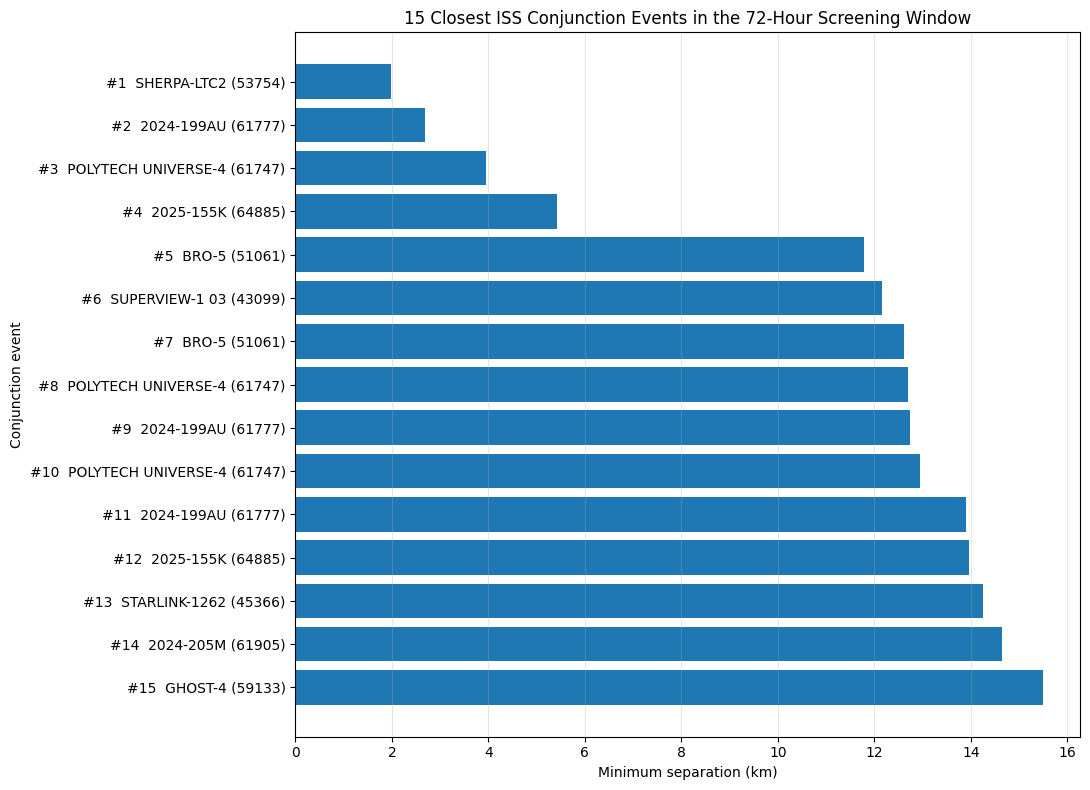

In [27]:
top15_final = final_events.head(15).copy()

top15_final["plot_label"] = [
    f"#{int(row.event_rank)}  {row.OBJECT_NAME} ({int(row.NORAD_CAT_ID)})"
    for _, row in top15_final.iterrows()
]

y_positions = np.arange(len(top15_final))

plt.figure(figsize=(11, 8))

plt.barh(
    y_positions,
    top15_final["refined_distance_km"]
)

plt.yticks(
    y_positions,
    top15_final["plot_label"]
)

plt.gca().invert_yaxis()

plt.xlabel("Minimum separation (km)")
plt.ylabel("Conjunction event")

plt.title(
    "15 Closest ISS Conjunction Events in the 72-Hour Screening Window"
)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "top15_iss_conjunctions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [28]:
project_summary = pd.DataFrame({
    "Metric": [
        "Active-satellite snapshot objects",
        "Objects entering full screen",
        "Coarse candidate intervals",
        "Refined candidate intervals",
        "Events below 50 km",
        "Unique objects below 50 km",
        "Events below 5 km",
        "Closest object",
        "Closest distance (km)",
        "SOCRATES reference events compared"
    ],
    "Value": [
        len(active_orbits),
        len(full_candidates),
        len(coarse_events),
        len(refined_events),
        len(final_events),
        final_events["NORAD_CAT_ID"].nunique(),
        len(events_below_5),
        final_events.iloc[0]["OBJECT_NAME"],
        round(
            final_events.iloc[0]["refined_distance_km"],
            6
        ),
        int(external_validation["refined_distance_km"].notna().sum())
    ]
})

display(project_summary)

final_events.to_csv(
    "ISS_full_catalog_screening_final.csv",
    index=False
)

external_validation.to_csv(
    "SOCRATES_external_validation.csv",
    index=False
)

project_summary.to_csv(
    "project_summary.csv",
    index=False
)

print("Final datasets saved.")


,Metric,Value
0,Active-satellite snapshot objects,16636
1,Objects entering full screen,7018
2,Coarse candidate intervals,11645
3,Refined candidate intervals,11642
4,Events below 50 km,878
5,Unique objects below 50 km,816
6,Events below 5 km,3
7,Closest object,SHERPA-LTC2
8,Closest distance (km),1.989251
9,SOCRATES reference events compared,3


Final datasets saved.


## 12. Limitations

- The source catalog is the saved CelesTrak **active-satellite** snapshot used in this experiment, not the complete debris catalog.
- The radial pre-filter is based on GP mean elements. It is a practical speed-up, not a proof that every possible conjunction in an arbitrary catalog would be retained.
- The 72-hour run uses a frozen GP snapshot. It does not model later orbit updates or maneuvers.
- I calculate TCA, miss distance, and relative speed only. There is no covariance information here, so this is **not** a collision-probability calculation or a replacement for operational CDMs.
- The ISS-module/docked-vehicle exclusion list is specific to this snapshot.
- In the historical study, GP element epochs are used as update markers. They should not be read as exact publication/availability times.
- SOCRATES is dynamic. The recorded comparison values can differ from the live site after newer GP data are ingested.

# Conclusions

Using the saved October 2026 GP files, I built a 72-hour ISS conjunction screener that starts with 16,636 active objects, reduces the set before propagation, keeps separate encounter intervals, and refines each candidate around its local minimum.

For this frozen dataset, the closest three recovered events were SHERPA-LTC2, 2024-199AU, and POLYTECH UNIVERSE-4. Their ranges and relative speeds matched the SOCRATES values I had recorded for the same experiment to the precision shown by SOCRATES.

The historical ISS–POLYTECH test gave a different result from what I initially expected: the predicted TCA stayed within about 1.6 seconds across the GP history, while the predicted miss distance moved from roughly 0.35 km to 14.84 km. For this one event, timing was much more stable than miss distance.

I would not generalize that result from a single conjunction, but it shows why the epoch of the orbital data matters and why a close-approach result should always be tied to the GP set that produced it.

In [29]:
import pandas as pd

expected = {
    "ISS_full_catalog_screening_final.csv": 878,
    "ISS_POLYTECH_historical_validation.csv": 22,
    "SOCRATES_external_validation.csv": 3,
    "project_summary.csv": 10
}

for filename, expected_rows in expected.items():
    df = pd.read_csv(filename)
    assert len(df) == expected_rows, f"Incorrect row count: {filename}"
    print(f"OK: {filename} — {len(df)} rows")

final = pd.read_csv("ISS_full_catalog_screening_final.csv")
external = pd.read_csv("SOCRATES_external_validation.csv")

assert final["NORAD_CAT_ID"].nunique() == 816
assert (final["refined_distance_km"] > 0).all()
assert (final["refined_distance_km"] < 50).all()
assert (final["refined_distance_km"] < 5).sum() == 3

assert set(external["NORAD_CAT_ID"].astype(int)) == {
    53754, 61777, 61747
}

print("\nBASIC INTEGRITY CHECKS PASSED")

OK: ISS_full_catalog_screening_final.csv — 878 rows
OK: ISS_POLYTECH_historical_validation.csv — 22 rows
OK: SOCRATES_external_validation.csv — 3 rows
OK: project_summary.csv — 10 rows

BASIC INTEGRITY CHECKS PASSED
